# Hammer test

### Imports

In [8]:
# Import packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [9]:
FOLDERS = {
    "../data/03_hammer_tests/test_01/00_intact": "No fracture hammer 1",
    "../data/03_hammer_tests/test_01/100_fractured": "100% Fracture hammer 1",
    "../data/03_hammer_tests/test_02/00_intact": "No fracture hammer 2",
    "../data/03_hammer_tests/test_02/100_fractured": "100% Fracture hammer 2",
    "../data/03_hammer_tests/test_03/00_intact": "No fracture hammer 3",
    "../data/03_hammer_tests/test_03/100_fractured": "100% Fracture hammer 3",
    "../data/03_hammer_tests/test_04/00_intact": "No fracture hammer 4",
    "../data/03_hammer_tests/test_04/100_fractured": "100% Fracture hammer 4"
}

group_data = {}

for folder, label in FOLDERS.items():

    csv_files = sorted(Path(folder).glob("*.csv"))

    if not csv_files:
        print(f"No CSV files found in {folder}")
        continue

    impedances = []
    frequency = None

    for csv_file in csv_files:

        df = pd.read_csv(csv_file)

        if frequency is None:
            frequency = df["frequency"].values

        # Skip incomplete sweeps
        if len(df) != len(frequency):
            print(
                f"Skipping {csv_file.name}: "
                f"{len(df)} rows instead of {len(frequency)}"
            )
            continue

        impedances.append(df["impedance"].values)

    if len(impedances) == 0:
        print(f"No valid files found in {folder}")
        continue

    impedances = np.vstack(impedances)

    group_data[label] = {
        "frequency": frequency,
        "mean": np.mean(impedances, axis=0),
        "std": np.std(impedances, axis=0),
        "raw": impedances,
        "n": len(csv_files)
    }

    print(f"{label}: {len(impedances)} files loaded")

No fracture hammer 1: 6 files loaded
100% Fracture hammer 1: 15 files loaded
No fracture hammer 2: 11 files loaded
100% Fracture hammer 2: 14 files loaded
No fracture hammer 3: 7 files loaded
100% Fracture hammer 3: 7 files loaded
No fracture hammer 4: 9 files loaded
100% Fracture hammer 4: 9 files loaded


### Outlier detection

In [10]:
print("OUTLIER REPORT")
print("=" * 40)

for group_name, data in group_data.items():

    sweep_means = np.mean(
        data["raw"],
        axis=1
    )

    z_scores = np.abs(
        zscore(sweep_means)
    )

    outliers = np.where(
        z_scores > 2.5
    )[0]

    print(f"\n{group_name}")

    if len(outliers) == 0:
        print("No outliers found")

    else:
        print(f"Outliers: {outliers}")

OUTLIER REPORT

No fracture hammer 1
No outliers found

100% Fracture hammer 1
No outliers found

No fracture hammer 2
Outliers: [3]

100% Fracture hammer 2
Outliers: [9]

No fracture hammer 3
No outliers found

100% Fracture hammer 3
No outliers found

No fracture hammer 4
Outliers: [0]

100% Fracture hammer 4
No outliers found


### Mean and standard deviation plot

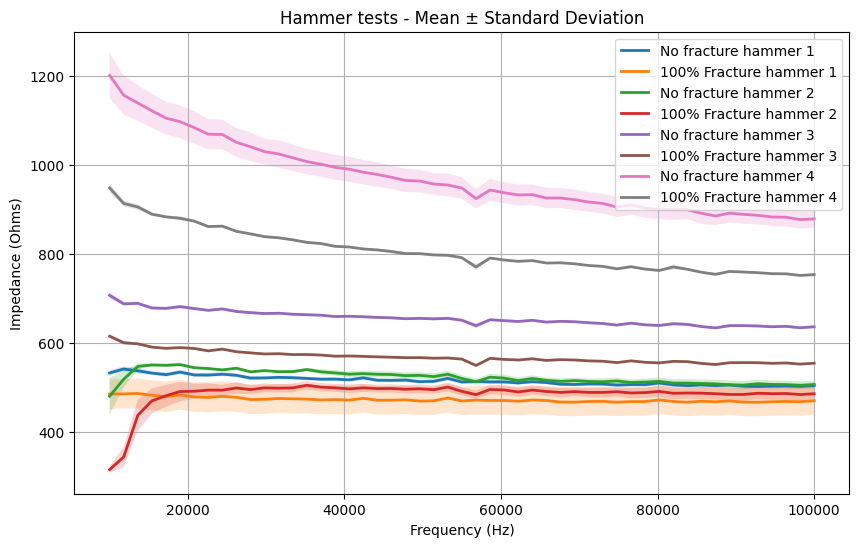

In [11]:
#plot all the relative changes for each hammer
plt.figure(figsize=(10, 6))

for group_name, data in group_data.items():
    plt.plot(
        data["frequency"],
        data["mean"],
        linewidth=2,
        label=group_name
    )

    plt.fill_between(
        data["frequency"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Impedance (Ohms)")
plt.title("Hammer tests - Mean ± Standard Deviation")
plt.legend()
plt.grid()

plt.savefig("../figures/not_in_paper/03_hammer_test_analysis_standard_deviation.png", dpi=300)
plt.show()

### Plot in individual plots

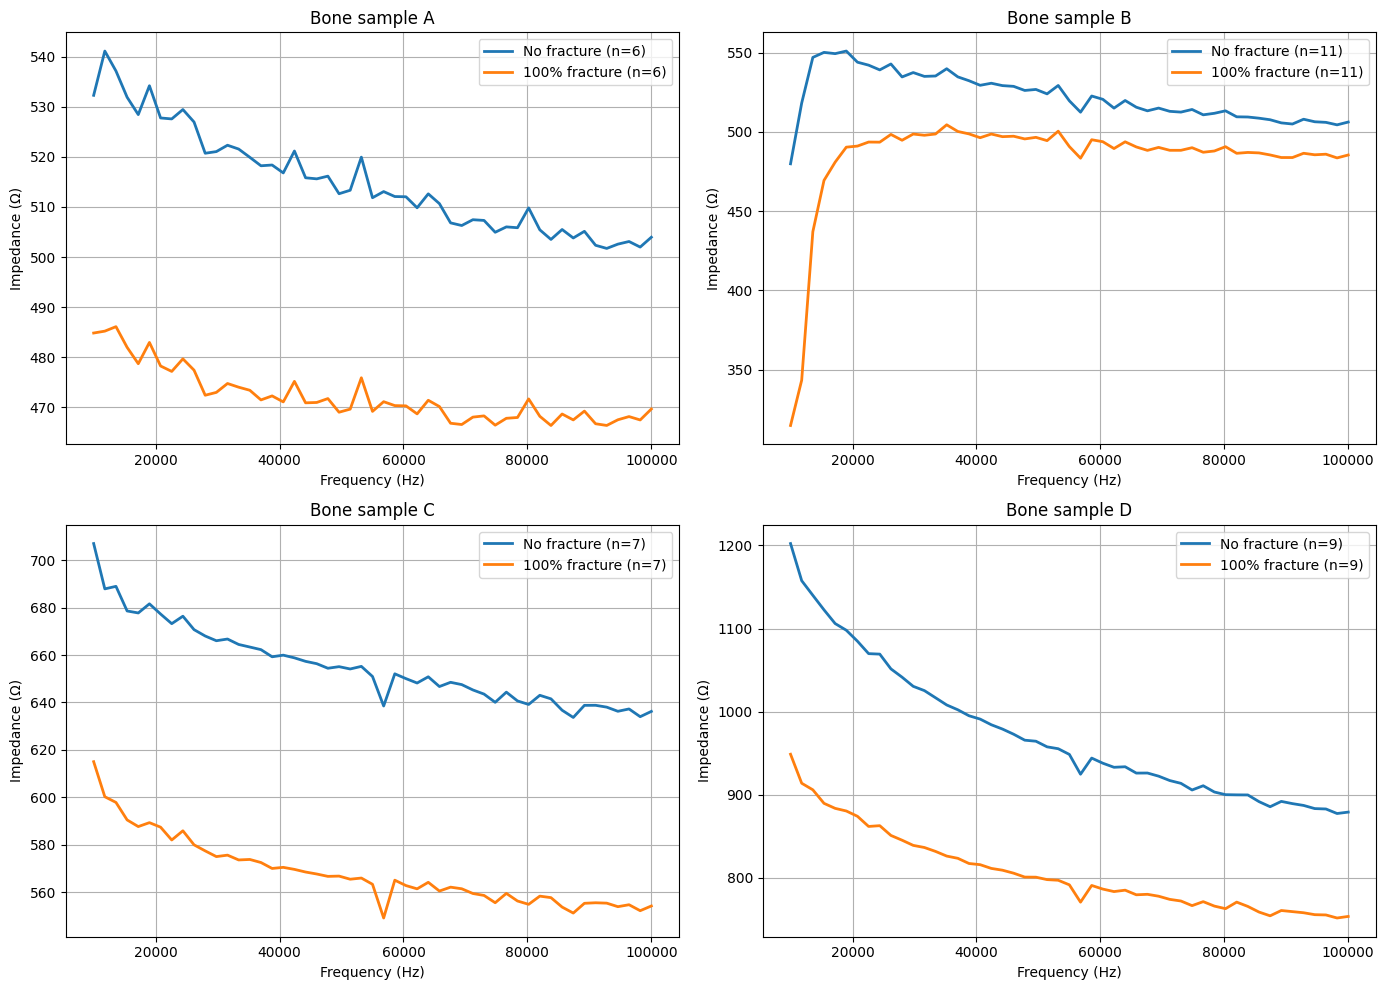

In [12]:
import matplotlib.pyplot as plt

specimen_names = {
    1: "Bone sample A",
    2: "Bone sample B",
    3: "Bone sample C",
    4: "Bone sample D"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, hammer in enumerate([1, 2, 3, 4]):

    intact_key = f"No fracture hammer {hammer}"
    fracture_key = f"100% Fracture hammer {hammer}"

    if intact_key not in group_data or fracture_key not in group_data:
        print(f"Missing data for hammer {hammer}")
        continue

    freq = group_data[intact_key]["frequency"]

    axes[idx].plot(
        freq,
        group_data[intact_key]["mean"],
        label=f"No fracture (n={group_data[intact_key]['n']})",

        linewidth=2
    )

    axes[idx].plot(
        freq,
        group_data[fracture_key]["mean"],
        label=f"100% fracture (n={group_data[intact_key]['n']})",
        linewidth=2
    )

    axes[idx].set_title(specimen_names[hammer])
    axes[idx].set_xlabel("Frequency (Hz)")
    axes[idx].set_ylabel("Impedance (Ω)")
    axes[idx].grid(True)
    axes[idx].legend()

plt.tight_layout()
plt.savefig("../figures/hammer_test_hammer_sample_grid_plot.png", dpi=300)
plt.show()

### Changed to individual healthy measurement

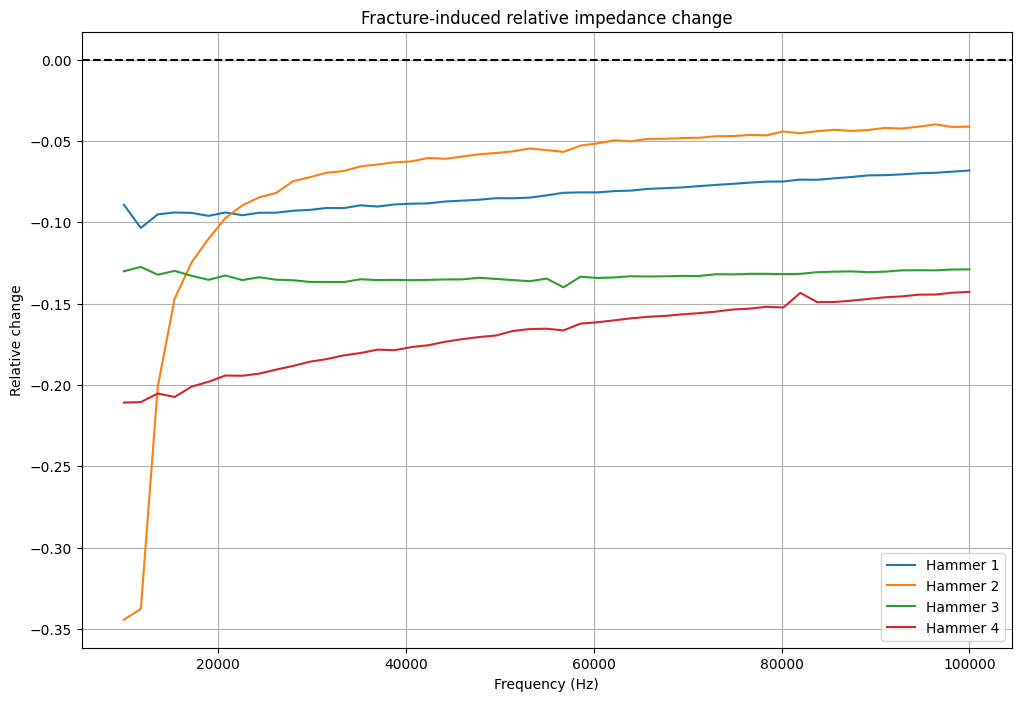

In [13]:
import matplotlib.pyplot as plt
import numpy as np

relative_changes = {}

plt.figure(figsize=(12, 8))

for hammer in [1, 2, 3, 4]:

    intact_key = f"No fracture hammer {hammer}"
    fracture_key = f"100% Fracture hammer {hammer}"

    if intact_key not in group_data or fracture_key not in group_data:
        continue

    freq = group_data[intact_key]["frequency"]

    intact_mean = group_data[intact_key]["mean"]
    fracture_mean = group_data[fracture_key]["mean"]

    # Relative change
    relative_change = (fracture_mean - intact_mean) / intact_mean

    relative_changes[f"hammer_{hammer}"] = relative_change

    plt.plot(
        freq,
        relative_change,
        label=f"Hammer {hammer}"
    )

plt.axhline(0, color="black", linestyle="--")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative change")
plt.title("Fracture-induced relative impedance change")
plt.legend()
plt.grid(True)
plt.show()